# Respiratory Disease Risk Prediction


#### Import libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import recall_score, f1_score, accuracy_score, roc_auc_score, precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import shap
import numpy as np
import lightgbm as lgb
from collections import Counter
import os
import joblib
import pickle


#LOADING DATASETS

In [2]:
#lOAD HOSPITAL
hospital_df= pd.read_csv('Datasets/Royalwood_Cancer_Center_Synthetic_Respiratory_Data.csv')

# LOAD AIR QUALITY DATASET
air_df= pd.read_csv('Datasets/SouthernAfrica_Sentinel5P.csv')


In [3]:
hospital_df.head()

,hospital,country,patient_id,Cough,Wheezing,Shortness_Breath,Chest_Pain,Smoking,Age,Gender,Exposure,Number_of_Positive_TB_Diagnosis_in_Family,Other_Respiratory_Illness_Past_Diagnosis,TB_Diagnosis,HIV_Diagnosis
0,Royalwood Cancer Center,Zimbabwe,RCC0000014,No,No,No,No,No,37,Female,Moderate,0,NaN,-,+
1,Royalwood Cancer Center,South Africa,RCC0000015,No,No,Yes,No,Yes,42,Female,Low,0,NaN,-,+
2,Royalwood Cancer Center,South Africa,RCC0000016,Yes,No,No,No,No,24,Male,Moderate,1,NaN,-,+
3,Royalwood Cancer Center,Botswana,RCC0000017,No,No,No,No,No,50,Male,Moderate,0,NaN,-,-
4,Royalwood Cancer Center,Lesotho,RCC0000018,No,No,No,No,No,65,Female,High,0,NaN,-,+


In [4]:
air_df.head()

,system:index,country,date,NO2,SO2,CO,O3,year
0,gen_000000,Botswana,2025/05/09,0.000029,0.000081,0.034446,0.135624,2025
1,gen_000001,Swaziland,2026/10/27,0.000042,0.000126,0.038905,NaN,2026
2,gen_000002,South Africa,2023/09/20,0.000067,0.000248,0.059781,NaN,2023
3,gen_000003,Mozambique,2022/02/21,0.000024,0.000119,0.032885,0.117508,2022
4,gen_000004,Mozambique,2018/01/17,0.000027,0.000111,0.027862,0.119665,2018


# DATA CLEANING AND PREPROCESSING



In [5]:
air_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   system:index  100000 non-null  str    
 1   country       100000 non-null  str    
 2   date          100000 non-null  str    
 3   NO2           92661 non-null   float64
 4   SO2           92461 non-null   float64
 5   CO            92597 non-null   float64
 6   O3            92490 non-null   float64
 7   year          100000 non-null  int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 8.9 MB


In [6]:
air_df = air_df.dropna()

In [7]:
hospital_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 249987 entries, 0 to 249986
Data columns (total 15 columns):
 #   Column                                     Non-Null Count   Dtype
---  ------                                     --------------   -----
 0   hospital                                   249987 non-null  str  
 1   country                                    249987 non-null  str  
 2   patient_id                                 249987 non-null  str  
 3   Cough                                      249987 non-null  str  
 4   Wheezing                                   249987 non-null  str  
 5   Shortness_Breath                           249987 non-null  str  
 6   Chest_Pain                                 249987 non-null  str  
 7   Smoking                                    249987 non-null  str  
 8   Age                                        249987 non-null  int64
 9   Gender                                     249987 non-null  str  
 10  Exposure                                   

## Patient Risk Assessment

In [8]:
#Cleaning the data so that they corectly match by removing any leading and
#strailing spaces from text
hospital_df.columns = hospital_df.columns.str.strip()
air_df.columns = air_df.columns.str.strip()

# Standardize naming differences
air_df['country'] = air_df['country'].replace({'Swaziland': 'Eswatini'})

#contry level enviromental features; air quality focusing on countries only
pollution_stats = air_df.groupby('country').agg({'NO2': ['mean'],
'SO2': ['mean'],
'CO': ['mean'],
'O3': ['mean']}).reset_index()

## flattening column names so that we can easily merge
pollution_stats.columns = ['country',
                           'NO2_mean',
                            'SO2_mean',
                            'CO_mean',
                            'O3_mean']

# Standardize each pollutant to generate Air Quality Index Column
scaler = StandardScaler()

pollution_stats[['O3_mean','NO2_mean','CO_mean','SO2_mean']] = scaler.fit_transform(
    pollution_stats[['O3_mean','NO2_mean','CO_mean','SO2_mean']]
)
# compute the average
pollution_stats['AQI'] = (
    pollution_stats['O3_mean'] +
    pollution_stats['NO2_mean'] +
    pollution_stats['CO_mean'] +
    pollution_stats['SO2_mean']
) / 4


#Merge with Hospital data; all countries from hospital, matching data from pollution stats
merged_df = pd.merge(hospital_df,pollution_stats,on='country',how='left')

# checking for duplicates
merged_df.duplicated().sum()

# Dropping Duplicates
merged_df = merged_df.drop_duplicates()

columns_to_drop = ['hospital', 'patient_id','O3_mean','NO2_mean','CO_mean','SO2_mean']

for col in columns_to_drop:
    if col in merged_df.columns:
        merged_df.drop(columns=col, inplace=True)

merged_df = merged_df.drop_duplicates()

# checking for remaining rows after removing duplicates
merged_df.head()

,country,Cough,Wheezing,Shortness_Breath,Chest_Pain,Smoking,Age,Gender,Exposure,Number_of_Positive_TB_Diagnosis_in_Family,Other_Respiratory_Illness_Past_Diagnosis,TB_Diagnosis,HIV_Diagnosis,AQI
0,Zimbabwe,No,No,No,No,No,37,Female,Moderate,0,NaN,-,+,-0.075914
1,South Africa,No,No,Yes,No,Yes,42,Female,Low,0,NaN,-,+,2.147937
2,South Africa,Yes,No,No,No,No,24,Male,Moderate,1,NaN,-,+,2.147937
3,Botswana,No,No,No,No,No,50,Male,Moderate,0,NaN,-,-,-0.835190
4,Lesotho,No,No,No,No,No,65,Female,High,0,NaN,-,+,-0.611621


In [9]:
merged_df.shape

(93875, 14)

In [10]:
#Encoding all the categoral features

df_copy = merged_df.copy()

df_copy["TB_Diagnosis"] = df_copy["TB_Diagnosis"].replace({
    "+": 1,
    "-": 0
})

df_copy["HIV_Diagnosis"] = df_copy["HIV_Diagnosis"].replace({
    "+": 1,
    "-": 0
})
df_copy['Other_Respiratory_Illness_Past_Diagnosis'] = df_copy['Other_Respiratory_Illness_Past_Diagnosis'].notna().astype(int)

non_numeric_cols = [
    col for col in df_copy.columns
    if not pd.api.types.is_numeric_dtype(df_copy[col])
]

encoders = {}

for col in non_numeric_cols:
  if col != "Exposure":
        le = LabelEncoder()
        df_copy[col] = le.fit_transform(df_copy[col])
        encoders[col] = le

encoder = OrdinalEncoder(categories=[["Low", "Moderate", "High"]])
df_copy[["Exposure"]] = encoder.fit_transform(df_copy[["Exposure"]])

df_copy["Exposure"] = df_copy["Exposure"].astype(int)


df_copy.head()

,country,Cough,Wheezing,Shortness_Breath,Chest_Pain,Smoking,Age,Gender,Exposure,Number_of_Positive_TB_Diagnosis_in_Family,Other_Respiratory_Illness_Past_Diagnosis,TB_Diagnosis,HIV_Diagnosis,AQI
0,5,0,0,0,0,0,37,0,1,0,0,0,1,-0.075914
1,4,0,0,1,0,1,42,0,0,0,0,0,1,2.147937
2,4,1,0,0,0,0,24,1,1,1,0,0,1,2.147937
3,0,0,0,0,0,0,50,1,1,0,0,0,0,-0.835190
4,2,0,0,0,0,0,65,0,2,0,0,0,1,-0.611621


# EXPLORATORY DATA ANALYSIS

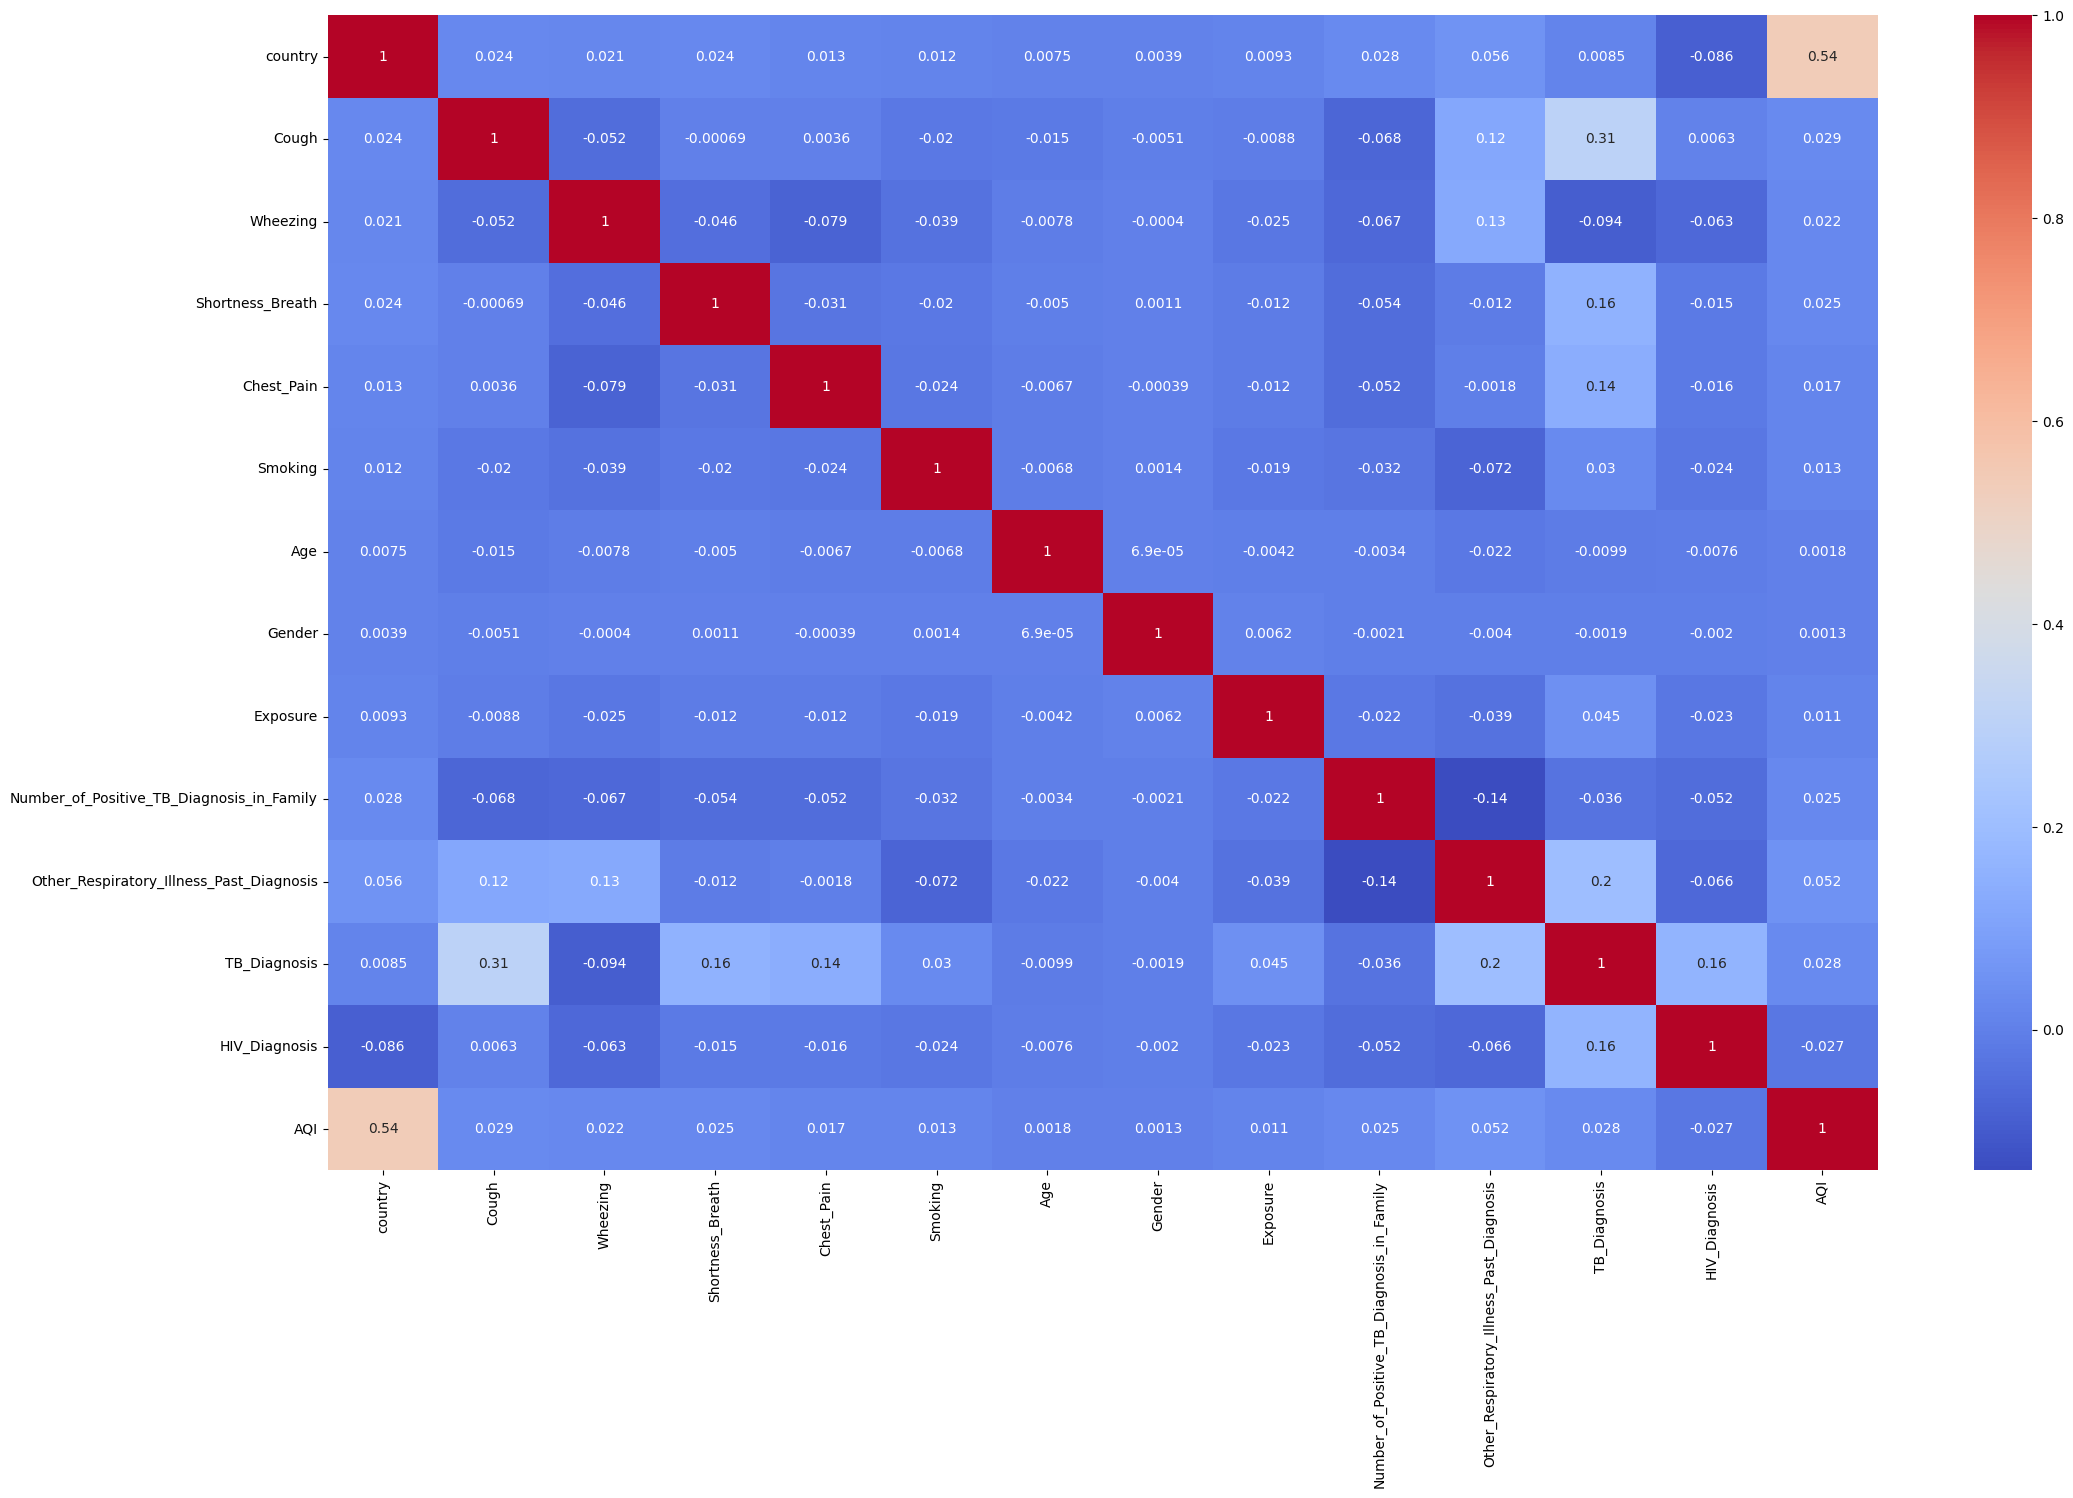

In [11]:
# checking for correlation in features
corr_matrix = df_copy.corr()

plt.figure(figsize=(25,15))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

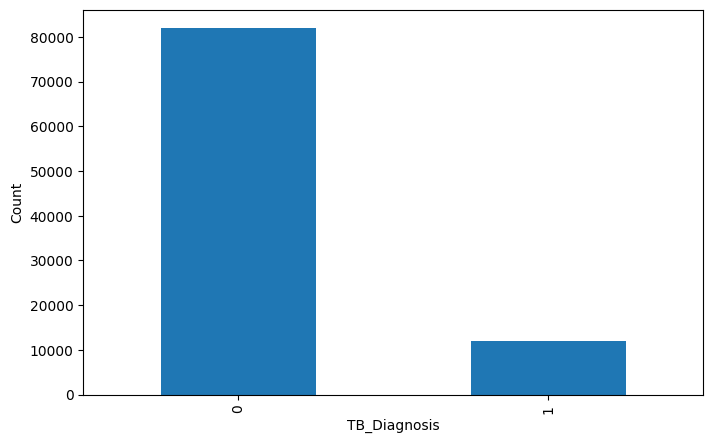

In [12]:
# Checking for data imbalance
counts = df_copy['TB_Diagnosis'].value_counts()

# Plot
plt.figure(figsize=(8,5))
counts.plot(kind='bar')

plt.xlabel('TB_Diagnosis')
plt.ylabel("Count")

plt.show()

# DATA SPLITTING

In [13]:
#RoyalWood Hospital dataset data spliting

# split our data into features and target
X = df_copy.drop(columns=['TB_Diagnosis'])
y = df_copy['TB_Diagnosis']

# divide the dataset into an 80% training set and a 20% testing set
X_train, X_test, y_train, y_test = train_test_split ( X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Original Training Class Distribution: {Counter(y_train)}")


Original Training Class Distribution: Counter({0: 65562, 1: 9538})


# MODEL TRAINING AND EVALUATION



In [14]:
# --- Calculate Weights for Class 0 (Sick) ---
num_sick = (y_train == 1).sum()     # Class 0 (Minority / Target)
num_healthy = (y_train == 0).sum()  # Class 1 (Majority)
ratio = num_healthy / num_sick

weights = {0: 1.0, 1: ratio}

print(f"Data balance ratio: {ratio:.2f}")
print("Weights successfully calculated.")

Data balance ratio: 6.87
Weights successfully calculated.


In [15]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        scale_pos_weight=ratio,      # ratio = majority/minority
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        scale_pos_weight=ratio,
        random_state=42,
        verbosity=-1
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("F1 Score", ascending=False)

,Model,Precision,Recall,F1 Score,ROC AUC,Balanced Accuracy
2,LightGBM,0.349049,0.739094,0.474166,0.848683,0.769309
1,XGBoost,0.351584,0.703020,0.468746,0.835095,0.757221
0,Random Forest,0.378166,0.363255,0.370561,0.767395,0.638189


Training LightGBM...


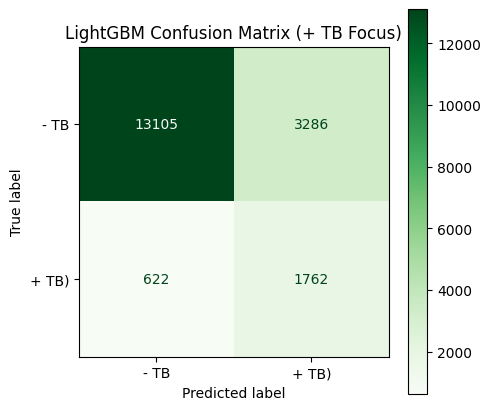


=== LightGBM Classification Report ===
                precision    recall  f1-score   support

- TB_Diagnosis       0.95      0.80      0.87     16391
+ TB_Diagnosis       0.35      0.74      0.47      2384

      accuracy                           0.79     18775
     macro avg       0.65      0.77      0.67     18775
  weighted avg       0.88      0.79      0.82     18775



In [16]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), "Model"
]

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

best_model = trained_models[best_model_name]

# Predictions from the best model
y_pred = best_model.predict(X_test)

print("Training LightGBM...")
# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    labels=[0, 1],
    display_labels=['- TB', '+ TB)'],
    cmap='Greens',
    ax=ax
)
plt.title("LightGBM Confusion Matrix (+ TB Focus)")
plt.show()

print("\n=== LightGBM Classification Report ===")
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['- TB_Diagnosis', '+ TB_Diagnosis']))

## SHAP Implementation

In [17]:
# initialize the SHAP TreeExplainer
# Then calculate the SHAP values on a slice of our test set to see each feature's impact.
explainer = shap.TreeExplainer(best_model)
# Subsampling 1000 rows; calculation fast and responsive while maintaining accuracy
shap_values = explainer(X_test)

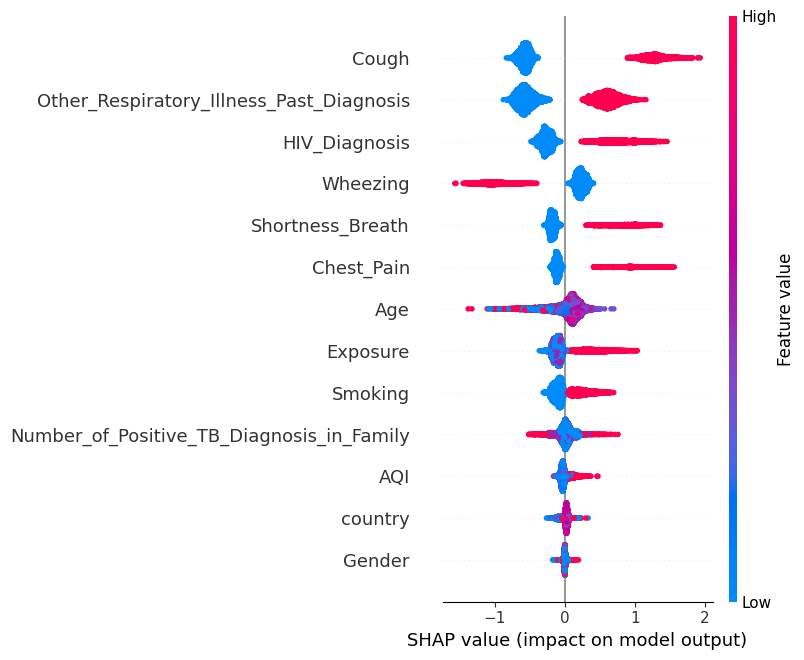

In [18]:
# plot the summary beeswarm chart to see what factors drive an ACTIVE infection
#ranks our patient and environmental features from most important to least important
# This reveals the relationship between clinical indicators, air pollution, and TB diagnoses.
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test)
plt.show()

This forest plot shows how each factor influences TB prediction:

Red points: high importance
Blue points : low importance

 The strongest predictors were found to be cough,
(strongest predictor)

Other respiratory illness history
HIV diagnosis
Shortness of breath
Chest pain


Blue points (left): Factors that decrease TB risk

Age (older = lower TB prediction)
Smoking, Exposure

In [19]:
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(explainer, "models/shap_explainer.pkl")


['models/shap_explainer.pkl']